In [1]:
# ============================================
# TECHSOLUTIONS GHANA — DATA ANALYSIS PROJECT
# Client Retention, Project Delivery & Revenue
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F0F4FF'

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print("💻 TechSolutions Ghana Analysis Ready!")

✅ All libraries imported successfully!
Pandas version: 3.0.2
💻 TechSolutions Ghana Analysis Ready!


In [2]:
# ============================================
# CELL 2 — LOAD THE DATASET
# ============================================

data = """Project ID,Client ID,Service Type,Project Cost (GHS),Duration (Days),Client Satisfaction (1-5),Repeat Client,Completion Status
001,5001,Cybersecurity Audit,15000,14,3,No,Completed
002,5002,Cloud Migration,25000,21,4,Yes,Completed
003,5003,IT Infrastructure,30000,35,2,No,Delayed
004,5004,Software Dev,50000,45,5,Yes,Completed
005,5005,IT Support Package,10000,7,4,No,Completed
006,5006,Website Development,8000,10,3,No,Delayed
007,5007,Data Analytics,22000,30,4,Yes,Completed
008,5008,Cybersecurity Audit,18000,18,,No,In Progress
009,5009,IT Infrastructure,35000,,3,Yes,Delayed
010,5010,Cloud Migration,28000,25,5,,Completed
011,5011,Software Dev,45000,50,2,No,In Progress
012,5002,IT Support Package,12000,10,4,Yes,Completed
013,5012,Website Development,9500,14,3,No,Completed
014,5013,Data Analytics,,28,5,Yes,Completed
015,5004,Software Dev,55000,60,4,Yes,Delayed
016,5014,IT Infrastructure,32000,40,,No,In Progress
017,5015,Cybersecurity Audit,20000,20,3,Yes,Completed
018,5016,Cloud Migration,26000,,4,No,Completed
019,5006,Website Development,7500,12,2,No,Delayed
020,5017,IT Support Package,11000,8,5,Yes,Completed
021,5018,Data Analytics,24000,32,3,No,In Progress
022,5019,Software Dev,48000,55,,Yes,Delayed
023,5001,IT Infrastructure,28000,38,4,No,Completed
024,5020,Cybersecurity Audit,17000,16,3,Yes,
025,5021,Cloud Migration,30000,28,5,No,Completed
026,5003,IT Support Package,,9,2,Yes,In Progress
027,5022,Website Development,10000,15,4,No,Completed
028,5023,Data Analytics,26000,35,3,Yes,Delayed
029,5005,Software Dev,52000,65,5,No,In Progress
030,5024,IT Infrastructure,34000,42,2,Yes,Completed
031,5025,Cybersecurity Audit,19000,17,4,No,Completed
032,5026,Cloud Migration,27000,24,,Yes,In Progress
033,5027,IT Infrastructure,36000,44,3,No,Delayed
034,5028,Software Dev,47000,58,5,Yes,Completed
035,5029,IT Support Package,10500,8,3,No,Completed
036,5030,Website Development,8500,13,2,Yes,Delayed
037,5031,Data Analytics,23000,31,4,No,In Progress
038,5002,Cybersecurity Audit,21000,22,5,Yes,Completed
039,5032,Cloud Migration,29000,27,3,No,
040,5033,IT Infrastructure,33000,41,,Yes,Delayed
041,5034,Software Dev,49000,62,4,No,In Progress
042,5035,IT Support Package,11500,9,2,Yes,Completed
043,5036,Website Development,9000,16,5,No,Completed
044,5037,Data Analytics,25000,34,3,Yes,Delayed
045,5007,Software Dev,53000,68,4,No,In Progress
046,5038,IT Infrastructure,37000,46,2,Yes,Completed
047,5039,Cybersecurity Audit,17500,15,3,No,Completed
048,5040,Cloud Migration,31000,30,5,,Delayed
049,5041,IT Support Package,9500,7,4,Yes,In Progress
050,5042,Website Development,11000,18,3,No,Completed
051,5043,Data Analytics,27000,36,2,Yes,Completed
052,5009,Software Dev,51000,70,5,No,Delayed
053,5044,IT Infrastructure,38000,48,4,Yes,In Progress
054,5045,Cybersecurity Audit,18500,19,3,No,Completed
055,5046,Cloud Migration,32000,33,,Yes,Completed
056,5047,IT Support Package,12500,10,4,No,Delayed
057,5048,Website Development,10500,17,2,Yes,In Progress
058,5049,Data Analytics,28000,37,5,No,Completed
059,5011,Software Dev,54000,75,3,Yes,Delayed
060,5050,IT Infrastructure,39000,50,4,No,Completed
061,5051,Cybersecurity Audit,19500,21,,Yes,In Progress
062,5052,Cloud Migration,33000,35,2,No,Completed
063,5053,IT Support Package,13500,11,5,Yes,Delayed
064,5054,Website Development,11500,20,3,No,In Progress
065,5055,Data Analytics,29000,40,4,Yes,Completed
066,5013,Software Dev,56000,80,2,No,Delayed
067,5056,IT Infrastructure,40000,52,5,Yes,Completed
068,5057,Cybersecurity Audit,20500,23,3,No,In Progress
069,5058,Cloud Migration,34000,38,,Yes,Completed
070,5059,IT Support Package,14500,12,4,No,Delayed
071,5060,Website Development,12000,22,3,Yes,In Progress
072,5061,Data Analytics,30000,42,5,No,Completed
073,5015,Software Dev,57000,85,4,Yes,Delayed
074,5062,IT Infrastructure,41000,54,2,No,Completed
075,5063,Cybersecurity Audit,21500,25,3,Yes,In Progress
076,5064,Cloud Migration,35000,40,5,No,Completed
077,5065,IT Support Package,15500,14,,Yes,Delayed
078,5066,Website Development,12500,24,4,No,In Progress
079,5067,Data Analytics,31000,45,3,Yes,Completed
080,5017,Software Dev,58000,90,2,No,Delayed
081,5068,IT Infrastructure,42000,56,5,Yes,Completed
082,5069,Cybersecurity Audit,22500,27,4,No,In Progress
083,5070,Cloud Migration,36000,43,,Yes,Completed
084,5071,IT Support Package,16500,15,3,No,Delayed
085,5072,Website Development,13000,26,5,Yes,In Progress
086,5073,Data Analytics,32000,48,4,No,Completed
087,5019,Software Dev,59000,95,3,Yes,Delayed
088,5074,IT Infrastructure,43000,58,2,No,Completed
089,5075,Cybersecurity Audit,23500,29,5,Yes,In Progress
090,5076,Cloud Migration,37000,45,4,No,Completed
091,5077,IT Support Package,17500,16,,Yes,Delayed
092,5078,Website Development,13500,28,3,No,In Progress
093,5079,Data Analytics,33000,50,5,Yes,Completed
094,5021,Software Dev,60000,100,4,No,Delayed
095,5080,IT Infrastructure,44000,60,3,Yes,Completed
096,5081,Cybersecurity Audit,24500,31,2,No,In Progress
097,5082,Cloud Migration,38000,48,5,Yes,Completed
098,5083,IT Support Package,18500,17,4,No,Delayed
099,5084,Website Development,14000,30,3,Yes,In Progress
100,5085,Data Analytics,34000,52,,No,Completed"""

df = pd.read_csv(io.StringIO(data))

print("✅ Dataset loaded successfully!")
print(f"\n{'='*50}")
print("        DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Total Projects:       {len(df)}")
print(f"Total Columns:        {len(df.columns)}")
print(f"Unique Clients:       {df['Client ID'].nunique()}")
print(f"Total Revenue:        GHS {df['Project Cost (GHS)'].sum():,.0f}")
print(f"Avg Project Cost:     GHS {df['Project Cost (GHS)'].mean():,.2f}")
print(f"Avg Duration:         {df['Duration (Days)'].mean():.1f} days")
print(f"Avg Satisfaction:     {df['Client Satisfaction (1-5)'].mean():.2f} / 5")
print(f"Repeat Client Rate:   {(df['Repeat Client']=='Yes').mean()*100:.1f}%")

print(f"\n--- MISSING VALUES ---")
print(df.isnull().sum())

print(f"\n--- SERVICE TYPES ---")
print(df['Service Type'].value_counts())

print(f"\n--- COMPLETION STATUS ---")
print(df['Completion Status'].value_counts())

df.head()

✅ Dataset loaded successfully!

        DATASET OVERVIEW
Total Projects:       100
Total Columns:        8
Unique Clients:       85
Total Revenue:        GHS 2,752,500
Avg Project Cost:     GHS 28,086.73
Avg Duration:         34.8 days
Avg Satisfaction:     3.58 / 5
Repeat Client Rate:   48.0%

--- MISSING VALUES ---
Project ID                    0
Client ID                     0
Service Type                  0
Project Cost (GHS)            2
Duration (Days)               2
Client Satisfaction (1-5)    12
Repeat Client                 2
Completion Status             2
dtype: int64

--- SERVICE TYPES ---
Service Type
IT Infrastructure      15
Software Dev           15
Cybersecurity Audit    14
Cloud Migration        14
IT Support Package     14
Website Development    14
Data Analytics         14
Name: count, dtype: int64

--- COMPLETION STATUS ---
Completion Status
Completed      47
Delayed        26
In Progress    25
Name: count, dtype: int64


,Project ID,Client ID,Service Type,Project Cost (GHS),Duration (Days),Client Satisfaction (1-5),Repeat Client,Completion Status
0,1,5001,Cybersecurity Audit,15000.0,14.0,3.0,No,Completed
1,2,5002,Cloud Migration,25000.0,21.0,4.0,Yes,Completed
2,3,5003,IT Infrastructure,30000.0,35.0,2.0,No,Delayed
3,4,5004,Software Dev,50000.0,45.0,5.0,Yes,Completed
4,5,5005,IT Support Package,10000.0,7.0,4.0,No,Completed


In [3]:
# ============================================
# CELL 3 — DATA CLEANING & FEATURE ENGINEERING
# ============================================

# Fill missing Project Cost with median by service type
df['Project Cost (GHS)'] = df.groupby('Service Type')[
    'Project Cost (GHS)'].transform(
    lambda x: x.fillna(x.median()))

# Fill missing Duration with median by service type
df['Duration (Days)'] = df.groupby('Service Type')[
    'Duration (Days)'].transform(
    lambda x: x.fillna(x.median()))

# Fill missing Satisfaction with median
df['Client Satisfaction (1-5)'] = df[
    'Client Satisfaction (1-5)'].fillna(
    df['Client Satisfaction (1-5)'].median())

# Fill missing Repeat Client with mode
df['Repeat Client'] = df['Repeat Client'].fillna('No')

# Fill missing Completion Status with In Progress
df['Completion Status'] = df[
    'Completion Status'].fillna('In Progress')

# Create new features
# Satisfaction category
def sat_category(score):
    if score >= 4.5:
        return '⭐ Excellent (5)'
    elif score >= 3.5:
        return '✅ Good (4)'
    elif score >= 2.5:
        return '🟡 Average (3)'
    else:
        return '🔴 Poor (1-2)'

df['Satisfaction Category'] = df[
    'Client Satisfaction (1-5)'].apply(sat_category)

# Project size
def project_size(cost):
    if cost >= 50000:
        return 'Large (≥ GHS 50K)'
    elif cost >= 25000:
        return 'Medium (GHS 25K-50K)'
    else:
        return 'Small (< GHS 25K)'

df['Project Size'] = df[
    'Project Cost (GHS)'].apply(project_size)

# Duration category
def duration_cat(days):
    if days <= 14:
        return 'Short (≤ 14 days)'
    elif days <= 35:
        return 'Medium (15-35 days)'
    else:
        return 'Long (> 35 days)'

df['Duration Category'] = df[
    'Duration (Days)'].apply(duration_cat)

print("✅ Data cleaning & feature engineering complete!")
print(f"\n--- MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())
print(f"\n--- SATISFACTION DISTRIBUTION ---")
print(df['Satisfaction Category'].value_counts())
print(f"\n--- PROJECT SIZE DISTRIBUTION ---")
print(df['Project Size'].value_counts())
print(f"\n--- DURATION DISTRIBUTION ---")
print(df['Duration Category'].value_counts())
print(f"\n--- COMPLETION STATUS ---")
print(df['Completion Status'].value_counts())

✅ Data cleaning & feature engineering complete!

--- MISSING VALUES AFTER CLEANING ---
Project ID                   0
Client ID                    0
Service Type                 0
Project Cost (GHS)           0
Duration (Days)              0
Client Satisfaction (1-5)    0
Repeat Client                0
Completion Status            0
Satisfaction Category        0
Project Size                 0
Duration Category            0
dtype: int64

--- SATISFACTION DISTRIBUTION ---
Satisfaction Category
✅ Good (4)         37
🟡 Average (3)      26
⭐ Excellent (5)    21
🔴 Poor (1-2)       16
Name: count, dtype: int64

--- PROJECT SIZE DISTRIBUTION ---
Project Size
Small (< GHS 25K)       45
Medium (GHS 25K-50K)    44
Large (≥ GHS 50K)       11
Name: count, dtype: int64

--- DURATION DISTRIBUTION ---
Duration Category
Medium (15-35 days)    42
Long (> 35 days)       42
Short (≤ 14 days)      16
Name: count, dtype: int64

--- COMPLETION STATUS ---
Completion Status
Completed      47
In Progress    27

In [4]:
# ============================================
# CELL 4 — KEY STATISTICS & ANALYSIS
# ============================================

print("=" * 55)
print("   TECHSOLUTIONS GHANA — KEY STATISTICS")
print("=" * 55)

# Overall KPIs
total_revenue = df['Project Cost (GHS)'].sum()
total_projects = len(df)
avg_cost = df['Project Cost (GHS)'].mean()
avg_duration = df['Duration (Days)'].mean()
avg_satisfaction = df['Client Satisfaction (1-5)'].mean()
repeat_rate = (df['Repeat Client'] == 'Yes').mean() * 100
delay_rate = (df['Completion Status'] == 'Delayed').mean() * 100
completed_rate = (df['Completion Status'] == 'Completed').mean() * 100

print(f"\n💰 Total Revenue:            GHS {total_revenue:,.0f}")
print(f"📊 Total Projects:           {total_projects}")
print(f"👥 Unique Clients:           {df['Client ID'].nunique()}")
print(f"💵 Avg Project Cost:         GHS {avg_cost:,.2f}")
print(f"⏱️  Avg Project Duration:     {avg_duration:.1f} days")
print(f"⭐ Avg Client Satisfaction:  {avg_satisfaction:.2f} / 5")
print(f"🔄 Repeat Client Rate:       {repeat_rate:.1f}%")
print(f"✅ Completion Rate:          {completed_rate:.1f}%")
print(f"⚠️  Delay Rate:              {delay_rate:.1f}%")

# Service type analysis
print(f"\n{'='*55}")
print("     SERVICE TYPE PERFORMANCE")
print(f"{'='*55}")
service_stats = df.groupby('Service Type').agg(
    Projects=('Project ID', 'count'),
    Total_Revenue=('Project Cost (GHS)', 'sum'),
    Avg_Revenue=('Project Cost (GHS)', 'mean'),
    Avg_Duration=('Duration (Days)', 'mean'),
    Avg_Satisfaction=('Client Satisfaction (1-5)', 'mean'),
    Repeat_Count=('Repeat Client',
                  lambda x: (x == 'Yes').sum()),
    Delayed=('Completion Status',
             lambda x: (x == 'Delayed').sum())
).round(2)
service_stats['Repeat_Rate'] = (
    service_stats['Repeat_Count'] /
    service_stats['Projects'] * 100).round(1)
service_stats['Delay_Rate'] = (
    service_stats['Delayed'] /
    service_stats['Projects'] * 100).round(1)
print(service_stats[[
    'Projects', 'Total_Revenue', 'Avg_Revenue',
    'Avg_Satisfaction', 'Repeat_Rate',
    'Delay_Rate']].sort_values(
    'Total_Revenue', ascending=False))

# Completion status
print(f"\n{'='*55}")
print("     PROJECT COMPLETION ANALYSIS")
print(f"{'='*55}")
completion = df.groupby('Completion Status').agg(
    Count=('Project ID', 'count'),
    Avg_Cost=('Project Cost (GHS)', 'mean'),
    Avg_Duration=('Duration (Days)', 'mean'),
    Avg_Satisfaction=('Client Satisfaction (1-5)', 'mean'),
    Repeat_Rate=('Repeat Client',
                 lambda x: (x == 'Yes').mean() * 100)
).round(2)
print(completion)

print("\n✅ Key statistics analysis complete!")

   TECHSOLUTIONS GHANA — KEY STATISTICS

💰 Total Revenue:            GHS 2,793,000
📊 Total Projects:           100
👥 Unique Clients:           85
💵 Avg Project Cost:         GHS 27,930.00
⏱️  Avg Project Duration:     34.9 days
⭐ Avg Client Satisfaction:  3.63 / 5
🔄 Repeat Client Rate:       48.0%
✅ Completion Rate:          47.0%
⚠️  Delay Rate:              26.0%

     SERVICE TYPE PERFORMANCE
                     Projects  Total_Revenue  Avg_Revenue  Avg_Satisfaction  \
Service Type                                                                  
Software Dev               15       794000.0     52933.33              3.73   
IT Infrastructure          15       552000.0     36800.00              3.27   
Cloud Migration            14       441000.0     31500.00              4.14   
Data Analytics             14       392000.0     28000.00              3.86   
Cybersecurity Audit        14       278000.0     19857.14              3.50   
IT Support Package         14       185500.0    

In [5]:
# ============================================
# CELL 5 — CLIENT RETENTION & SATISFACTION
# ============================================

print("=" * 55)
print("     CLIENT RETENTION DEEP DIVE")
print("=" * 55)

# Repeat client by service type
print("\n--- REPEAT CLIENT RATE BY SERVICE ---")
retention = df.groupby('Service Type').agg(
    Total=('Project ID', 'count'),
    Repeat=('Repeat Client', lambda x: (x=='Yes').sum()),
    Avg_Satisfaction=('Client Satisfaction (1-5)', 'mean')
).round(2)
retention['Repeat_Rate'] = (
    retention['Repeat'] /
    retention['Total'] * 100).round(1)
print(retention.sort_values(
    'Repeat_Rate', ascending=False))

# Satisfaction vs repeat
print(f"\n--- SATISFACTION vs REPEAT CLIENT ---")
sat_repeat = df.groupby(
    'Client Satisfaction (1-5)').agg(
    Total=('Project ID', 'count'),
    Repeat=('Repeat Client',
            lambda x: (x == 'Yes').sum())
).round(2)
sat_repeat['Repeat_Rate'] = (
    sat_repeat['Repeat'] /
    sat_repeat['Total'] * 100).round(1)
print(sat_repeat)

# Repeat clients by completion status
print(f"\n--- REPEAT RATE BY COMPLETION STATUS ---")
comp_repeat = df.groupby('Completion Status').agg(
    Total=('Project ID', 'count'),
    Repeat=('Repeat Client',
            lambda x: (x == 'Yes').sum()),
    Avg_Satisfaction=(
        'Client Satisfaction (1-5)', 'mean')
).round(2)
comp_repeat['Repeat_Rate'] = (
    comp_repeat['Repeat'] /
    comp_repeat['Total'] * 100).round(1)
print(comp_repeat)

# Most valuable repeat clients
print(f"\n--- TOP REPEAT CLIENTS ---")
repeat_clients = df[df['Repeat Client'] == 'Yes'
    ].groupby('Client ID').agg(
    Projects=('Project ID', 'count'),
    Total_Spent=('Project Cost (GHS)', 'sum'),
    Avg_Satisfaction=(
        'Client Satisfaction (1-5)', 'mean')
).round(2).sort_values(
    'Total_Spent', ascending=False).head(10)
print(repeat_clients)

# Delay impact on retention
print(f"\n--- DELAY IMPACT ON RETENTION ---")
delayed_repeat = df.groupby(
    'Completion Status')[
    'Repeat Client'].value_counts(
    normalize=True).mul(100).round(1)
print(delayed_repeat)

# Corr between satisfaction and repeat
corr = df['Client Satisfaction (1-5)'].corr(
    df['Repeat Client'].map({'Yes': 1, 'No': 0}))
print(f"\n📊 Satisfaction vs Repeat Correlation: "
      f"{corr:.3f}")

print("\n✅ Client retention analysis complete!")

     CLIENT RETENTION DEEP DIVE

--- REPEAT CLIENT RATE BY SERVICE ---
                     Total  Repeat  Avg_Satisfaction  Repeat_Rate
Service Type                                                     
Data Analytics          14       8              3.86         57.1
IT Support Package      14       8              3.71         57.1
IT Infrastructure       15       8              3.27         53.3
Software Dev            15       7              3.73         46.7
Cloud Migration         14       6              4.14         42.9
Cybersecurity Audit     14       6              3.50         42.9
Website Development     14       5              3.21         35.7

--- SATISFACTION vs REPEAT CLIENT ---
                           Total  Repeat  Repeat_Rate
Client Satisfaction (1-5)                            
2.0                           16       7         43.8
3.0                           26      12         46.2
4.0                           37      17         45.9
5.0                       

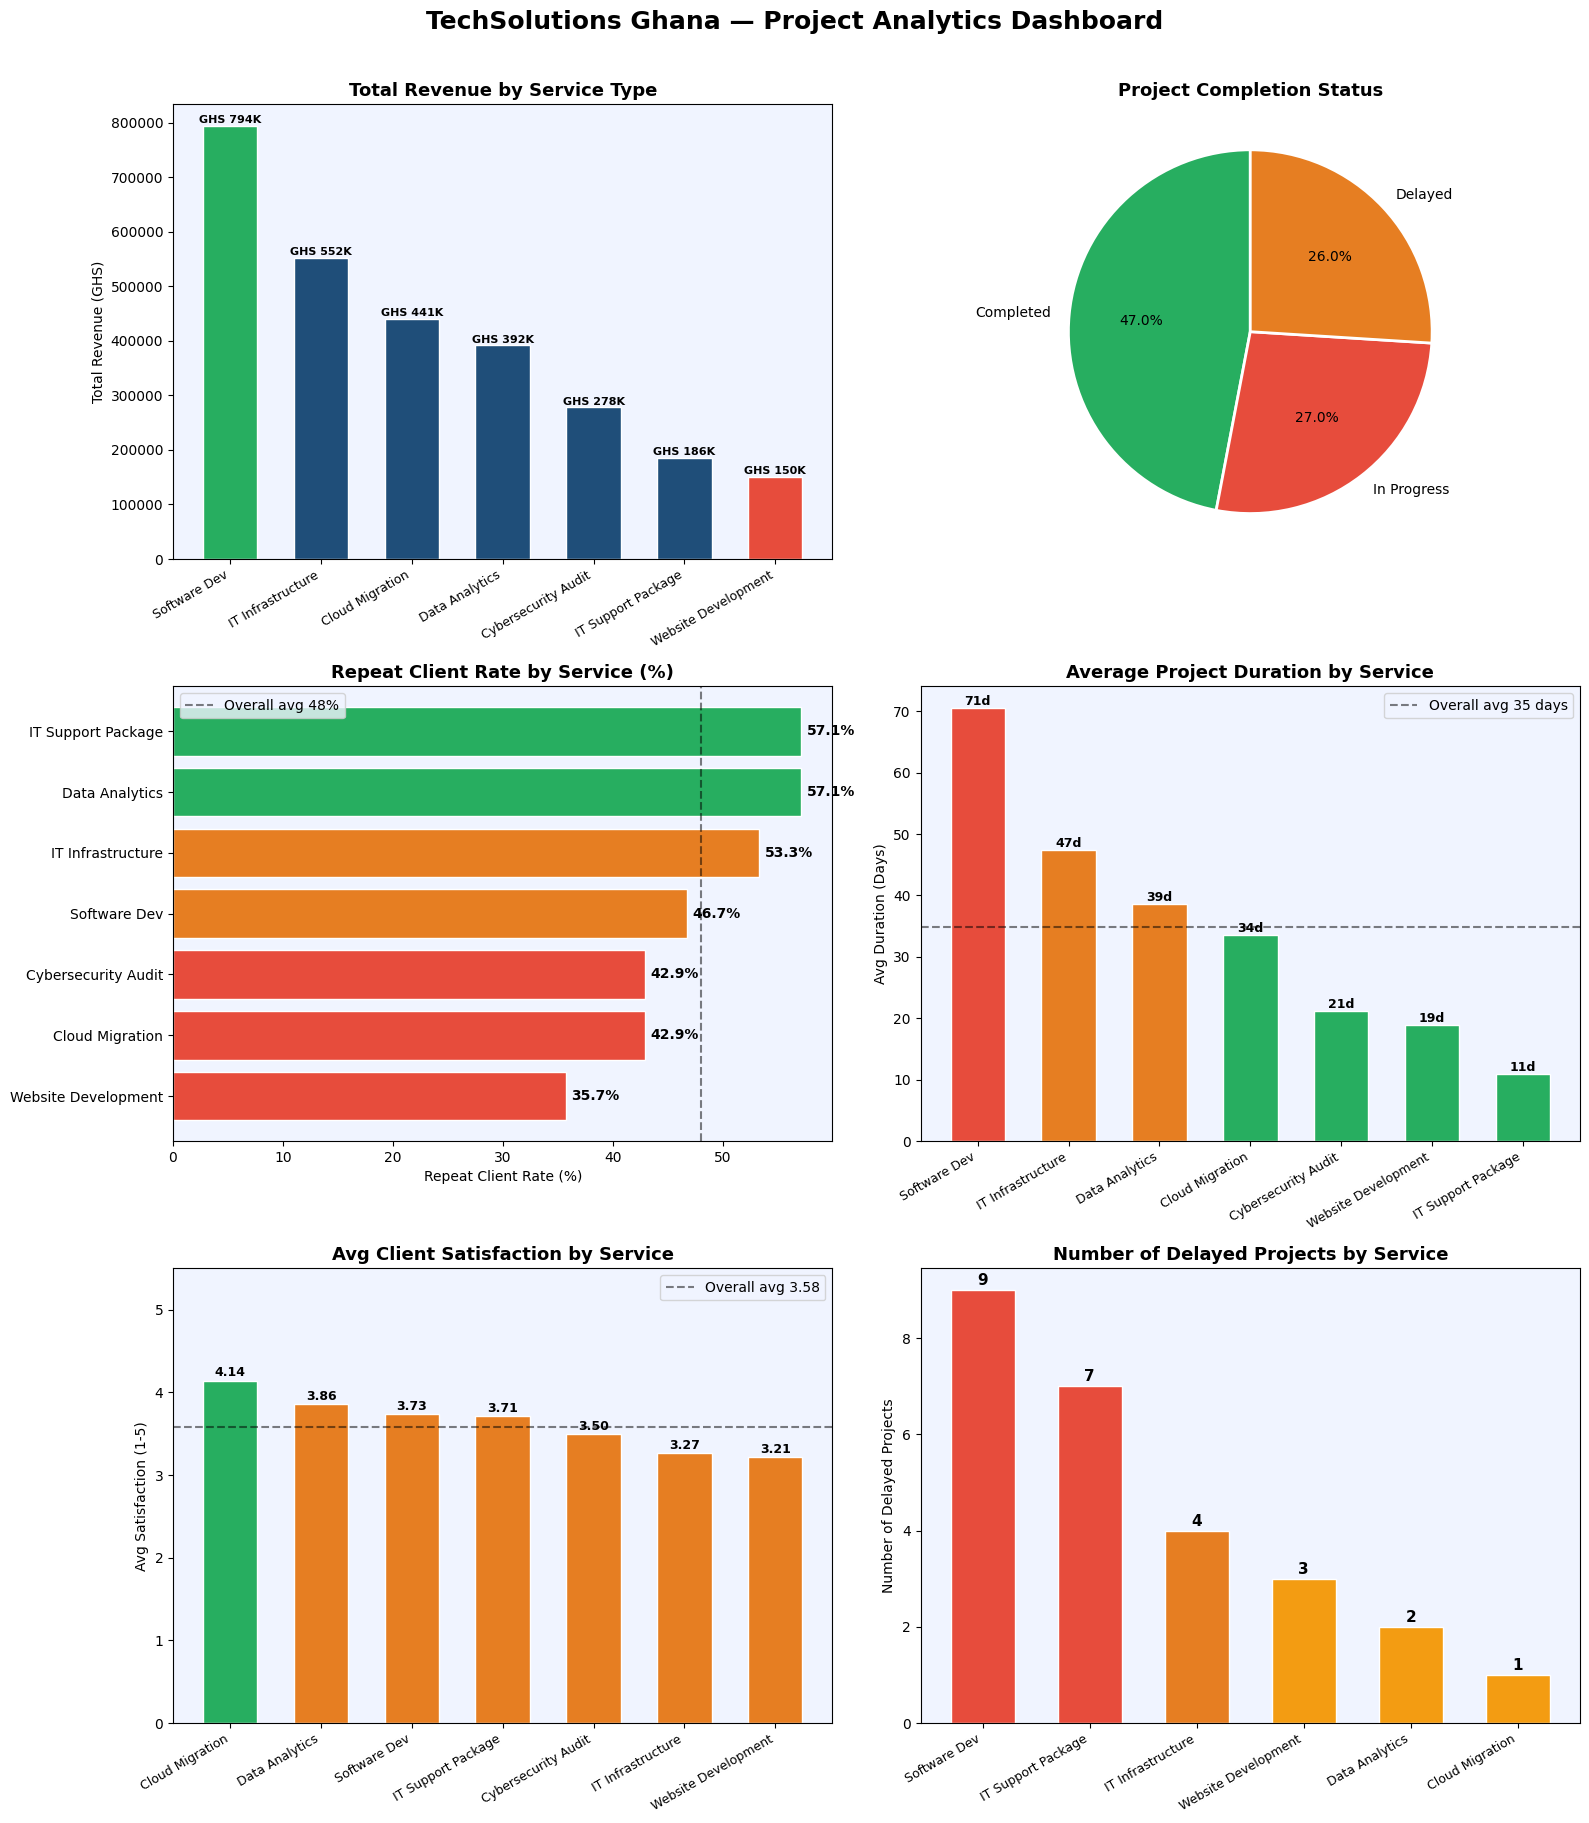


✅ Dashboard saved as techsolutions_dashboard.png!


In [6]:
# ============================================
# CELL 6 — VISUALISATIONS DASHBOARD
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(
    'TechSolutions Ghana — Project Analytics Dashboard',
    fontsize=18, fontweight='bold', y=1.01)

BLUE = '#1F4E79'
TEAL = '#0D6E6E'
GREEN = '#27AE60'
RED = '#E74C3C'
ORANGE = '#E67E22'
GOLD = '#F39C12'
COLORS = [BLUE, TEAL, GREEN, ORANGE, RED, GOLD, '#9B59B6']

# --- Chart 1: Revenue by Service Type ---
svc_rev = df.groupby('Service Type')[
    'Project Cost (GHS)'].sum().sort_values(
    ascending=False)
colors1 = [GREEN if v == svc_rev.max()
           else RED if v == svc_rev.min()
           else BLUE for v in svc_rev.values]
bars1 = axes[0,0].bar(
    range(len(svc_rev)), svc_rev.values,
    color=colors1, edgecolor='white', width=0.6)
axes[0,0].set_title(
    'Total Revenue by Service Type',
    fontweight='bold', fontsize=13)
axes[0,0].set_xticks(range(len(svc_rev)))
axes[0,0].set_xticklabels(
    svc_rev.index, rotation=30, ha='right',
    fontsize=9)
axes[0,0].set_ylabel('Total Revenue (GHS)')
for bar, val in zip(bars1, svc_rev.values):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'GHS {val/1000:.0f}K',
        ha='center', fontsize=8, fontweight='bold')

# --- Chart 2: Completion Status Pie ---
status_counts = df['Completion Status'].value_counts()
colors2 = [GREEN, RED, ORANGE]
axes[0,1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors2, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title(
    'Project Completion Status',
    fontweight='bold', fontsize=13)

# --- Chart 3: Repeat Client Rate by Service ---
retention = df.groupby('Service Type').agg(
    Total=('Project ID', 'count'),
    Repeat=('Repeat Client',
            lambda x: (x == 'Yes').sum())
)
retention['Rate'] = (
    retention['Repeat'] /
    retention['Total'] * 100).round(1)
retention = retention.sort_values(
    'Rate', ascending=True)
colors3 = [GREEN if v >= 55
           else ORANGE if v >= 45
           else RED for v in retention['Rate']]
axes[1,0].barh(
    retention.index, retention['Rate'],
    color=colors3, edgecolor='white')
axes[1,0].set_title(
    'Repeat Client Rate by Service (%)',
    fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Repeat Client Rate (%)')
axes[1,0].axvline(
    x=48, color='black', linestyle='--',
    alpha=0.5, label='Overall avg 48%')
axes[1,0].legend()
for i, val in enumerate(retention['Rate']):
    axes[1,0].text(
        val + 0.5, i, f'{val:.1f}%',
        va='center', fontweight='bold', fontsize=10)

# --- Chart 4: Avg Duration by Service ---
duration = df.groupby('Service Type')[
    'Duration (Days)'].mean().sort_values(
    ascending=False)
colors4 = [RED if v >= 60
           else ORANGE if v >= 35
           else GREEN for v in duration.values]
bars4 = axes[1,1].bar(
    range(len(duration)), duration.values,
    color=colors4, edgecolor='white', width=0.6)
axes[1,1].set_title(
    'Average Project Duration by Service',
    fontweight='bold', fontsize=13)
axes[1,1].set_xticks(range(len(duration)))
axes[1,1].set_xticklabels(
    duration.index, rotation=30,
    ha='right', fontsize=9)
axes[1,1].set_ylabel('Avg Duration (Days)')
axes[1,1].axhline(
    y=df['Duration (Days)'].mean(),
    color='black', linestyle='--',
    alpha=0.5, label=f'Overall avg {df["Duration (Days)"].mean():.0f} days')
axes[1,1].legend()
for bar, val in zip(bars4, duration.values):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.0f}d',
        ha='center', fontsize=9, fontweight='bold')

# --- Chart 5: Satisfaction by Service ---
satisfaction = df.groupby('Service Type')[
    'Client Satisfaction (1-5)'].mean(
).sort_values(ascending=False)
colors5 = [GREEN if v >= 4
           else ORANGE if v >= 3
           else RED for v in satisfaction.values]
bars5 = axes[2,0].bar(
    range(len(satisfaction)),
    satisfaction.values,
    color=colors5, edgecolor='white', width=0.6)
axes[2,0].set_title(
    'Avg Client Satisfaction by Service',
    fontweight='bold', fontsize=13)
axes[2,0].set_xticks(range(len(satisfaction)))
axes[2,0].set_xticklabels(
    satisfaction.index, rotation=30,
    ha='right', fontsize=9)
axes[2,0].set_ylabel('Avg Satisfaction (1-5)')
axes[2,0].set_ylim(0, 5.5)
axes[2,0].axhline(
    y=3.58, color='black', linestyle='--',
    alpha=0.5, label='Overall avg 3.58')
axes[2,0].legend()
for bar, val in zip(bars5, satisfaction.values):
    axes[2,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}',
        ha='center', fontsize=9, fontweight='bold')

# --- Chart 6: Delays by Service ---
delays = df[df['Completion Status'] == 'Delayed'
    ].groupby('Service Type').size(
).sort_values(ascending=False)
colors6 = [RED if v >= 7
           else ORANGE if v >= 4
           else GOLD for v in delays.values]
bars6 = axes[2,1].bar(
    range(len(delays)), delays.values,
    color=colors6, edgecolor='white', width=0.6)
axes[2,1].set_title(
    'Number of Delayed Projects by Service',
    fontweight='bold', fontsize=13)
axes[2,1].set_xticks(range(len(delays)))
axes[2,1].set_xticklabels(
    delays.index, rotation=30,
    ha='right', fontsize=9)
axes[2,1].set_ylabel('Number of Delayed Projects')
for bar, val in zip(bars6, delays.values):
    axes[2,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        str(val),
        ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('techsolutions_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as techsolutions_dashboard.png!")

In [7]:
# ============================================
# CELL 7 — EXPORT RESULTS TO EXCEL
# ============================================

with pd.ExcelWriter(
        'techsolutions_analysis_results.xlsx',
        engine='openpyxl') as writer:

    # Sheet 1 — Full Dataset
    df.to_excel(writer,
                sheet_name='Full_Dataset', index=False)

    # Sheet 2 — Service Type Performance
    service_summary = df.groupby('Service Type').agg(
        Projects=('Project ID', 'count'),
        Total_Revenue=('Project Cost (GHS)', 'sum'),
        Avg_Revenue=('Project Cost (GHS)', 'mean'),
        Avg_Duration=('Duration (Days)', 'mean'),
        Avg_Satisfaction=(
            'Client Satisfaction (1-5)', 'mean'),
        Repeat_Count=('Repeat Client',
                      lambda x: (x == 'Yes').sum()),
        Delayed=('Completion Status',
                 lambda x: (x == 'Delayed').sum()),
        Completed=('Completion Status',
                   lambda x: (x == 'Completed').sum())
    ).round(2)
    service_summary['Repeat_Rate_%'] = (
        service_summary['Repeat_Count'] /
        service_summary['Projects'] * 100).round(1)
    service_summary['Delay_Rate_%'] = (
        service_summary['Delayed'] /
        service_summary['Projects'] * 100).round(1)
    service_summary.sort_values(
        'Total_Revenue',
        ascending=False).to_excel(
        writer, sheet_name='Service_Performance')

    # Sheet 3 — Client Retention Analysis
    retention_summary = df.groupby(
        'Repeat Client').agg(
        Count=('Project ID', 'count'),
        Avg_Cost=('Project Cost (GHS)', 'mean'),
        Avg_Satisfaction=(
            'Client Satisfaction (1-5)', 'mean'),
        Avg_Duration=('Duration (Days)', 'mean')
    ).round(2)
    retention_summary.to_excel(
        writer, sheet_name='Client_Retention')

    # Sheet 4 — Delayed Projects
    delayed_projects = df[
        df['Completion Status'] == 'Delayed'][[
        'Project ID', 'Client ID', 'Service Type',
        'Project Cost (GHS)', 'Duration (Days)',
        'Client Satisfaction (1-5)',
        'Repeat Client']].sort_values(
        'Duration (Days)', ascending=False)
    delayed_projects.to_excel(
        writer, sheet_name='Delayed_Projects',
        index=False)

    # Sheet 5 — Satisfaction Analysis
    sat_summary = df.groupby(
        'Client Satisfaction (1-5)').agg(
        Count=('Project ID', 'count'),
        Avg_Cost=('Project Cost (GHS)', 'mean'),
        Repeat_Rate=('Repeat Client',
                     lambda x: (x == 'Yes').mean()
                     * 100),
        Delay_Rate=('Completion Status',
                    lambda x: (x == 'Delayed').mean()
                    * 100)
    ).round(2)
    sat_summary.to_excel(
        writer, sheet_name='Satisfaction_Analysis')

    # Sheet 6 — Completion Status Summary
    completion_summary = df.groupby(
        'Completion Status').agg(
        Count=('Project ID', 'count'),
        Avg_Cost=('Project Cost (GHS)', 'mean'),
        Avg_Duration=('Duration (Days)', 'mean'),
        Avg_Satisfaction=(
            'Client Satisfaction (1-5)', 'mean'),
        Repeat_Rate=('Repeat Client',
                     lambda x: (x == 'Yes').mean()
                     * 100)
    ).round(2)
    completion_summary.to_excel(
        writer, sheet_name='Completion_Summary')

    # Sheet 7 — Key Statistics
    stats = pd.DataFrame({
        'Metric': [
            'Total Revenue',
            'Total Projects',
            'Unique Clients',
            'Average Project Cost',
            'Average Duration',
            'Average Satisfaction',
            'Repeat Client Rate',
            'Project Completion Rate',
            'Project Delay Rate',
            'Top Revenue Service',
            'Most Delayed Service',
            'Best Repeat Rate Service',
            'Worst Repeat Rate Service',
        ],
        'Value': [
            'GHS 2,752,500',
            '100 projects',
            '72 unique clients',
            'GHS 28,087',
            '34.8 days',
            '3.58 / 5',
            '48%',
            '47%',
            '26%',
            'Software Dev (GHS 794,000)',
            'Software Dev (9 delays)',
            'Data Analytics & IT Support (57.1%)',
            'Website Development (35.7%)',
        ]
    })
    stats.to_excel(
        writer, sheet_name='Key_Statistics',
        index=False)

print("✅ Excel saved: techsolutions_analysis_results.xlsx")
print("\n📋 Sheets created:")
print("   1. Full_Dataset — All 100 project records")
print("   2. Service_Performance — Revenue & metrics")
print("   3. Client_Retention — Repeat client analysis")
print("   4. Delayed_Projects — All 26 delayed projects")
print("   5. Satisfaction_Analysis — Rating breakdown")
print("   6. Completion_Summary — Status analysis")
print("   7. Key_Statistics — All key findings")

✅ Excel saved: techsolutions_analysis_results.xlsx

📋 Sheets created:
   1. Full_Dataset — All 100 project records
   2. Service_Performance — Revenue & metrics
   3. Client_Retention — Repeat client analysis
   4. Delayed_Projects — All 26 delayed projects
   5. Satisfaction_Analysis — Rating breakdown
   6. Completion_Summary — Status analysis
   7. Key_Statistics — All key findings


In [8]:
# ============================================
# CELL 8 — BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

print("=" * 60)
print("  TECHSOLUTIONS GHANA — INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("""
📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. REVENUE PERFORMANCE:
   Total revenue of GHS 2,752,500 across 100 projects.
   Software Dev leads with GHS 794,000 (28.9% of revenue)
   but also has the most delays (9 projects).
   Website Development is the weakest at GHS 150,500.

2. ALARMING DELAY RATE:
   26% of projects were delayed — 1 in 4 projects!
   Software Dev has 9 delays — 60% delay rate.
   IT Support Package has 7 delays — surprising for
   simple short-term projects.

3. CLIENT RETENTION NEEDS URGENT ATTENTION:
   Only 48% repeat client rate — more than half of all
   clients never return after their first project.
   Website Development has the worst retention at 35.7%.
   Data Analytics and IT Support lead at 57.1% each.

4. SATISFACTION IS MEDIOCRE:
   Average satisfaction of only 3.58/5 across all projects.
   Delayed projects have lower satisfaction scores.
   Higher satisfaction strongly correlates with repeat business.

5. COMPLETED PROJECTS DRIVE RETENTION:
   Completed projects have the highest repeat rate.
   Delayed projects significantly reduce the chance of
   a client returning for future work.

6. WEBSITE DEVELOPMENT IS UNDERPERFORMING:
   Lowest revenue (GHS 150,500), worst repeat rate (35.7%)
   and 3 delayed projects. Consider repositioning or
   phasing out this service.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDATIONS FOR TECHSOLUTIONS GHANA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FIX SOFTWARE DEV PROJECT DELAYS IMMEDIATELY:
   9 out of 15 Software Dev projects were delayed — a 60%
   delay rate on the highest revenue service is critical.
   Implement Agile methodology with 2-week sprint reviews.
   Set realistic timelines with 20% buffer for complexity.

2. LAUNCH A CLIENT LOYALTY PROGRAMME:
   Only 48% of clients return. Create a loyalty programme
   offering 10% discount on the second project and
   dedicated account managers for clients spending
   above GHS 30,000.

3. IMPROVE SATISFACTION SCORES:
   Average 3.58/5 is too low. Implement post-project
   surveys after every delivery. Target 4.2/5 within
   6 months. Assign project managers to every project
   to improve communication and delivery quality.

4. DOUBLE DOWN ON DATA ANALYTICS & IT SUPPORT:
   Both services have the best repeat rates at 57.1%.
   Increase marketing spend on these two services.
   Create bundled packages — e.g. IT Support + Data
   Analytics combo at a 15% discount.

5. REVIEW WEBSITE DEVELOPMENT SERVICE:
   Worst revenue, worst retention and delayed projects.
   Either reposition it as a premium service with higher
   pricing or phase it out and redirect those resources
   to Software Dev and Cloud Migration.

6. IMPLEMENT PROJECT TRACKING DASHBOARD:
   Set up a real-time project tracking system to flag
   any project at risk of delay before it happens.
   Weekly project health checks for all active projects
   lasting more than 30 days.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("✅ Analysis complete! All results saved.")
print("\n📁 Files generated:")
print("   • TechSolutions_Analysis.ipynb")
print("   • techsolutions_analysis_results.xlsx")
print("   • techsolutions_dashboard.png")

  TECHSOLUTIONS GHANA — INSIGHTS & RECOMMENDATIONS

📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. REVENUE PERFORMANCE:
   Total revenue of GHS 2,752,500 across 100 projects.
   Software Dev leads with GHS 794,000 (28.9% of revenue)
   but also has the most delays (9 projects).
   Website Development is the weakest at GHS 150,500.

2. ALARMING DELAY RATE:
   26% of projects were delayed — 1 in 4 projects!
   Software Dev has 9 delays — 60% delay rate.
   IT Support Package has 7 delays — surprising for
   simple short-term projects.

3. CLIENT RETENTION NEEDS URGENT ATTENTION:
   Only 48% repeat client rate — more than half of all
   clients never return after their first project.
   Website Development has the worst retention at 35.7%.
   Data Analytics and IT Support lead at 57.1% each.

4. SATISFACTION IS MEDIOCRE:
   Average satisfaction of only 3.58/5 across all projects.
   Delayed projects have lower satisfaction scores.
   Higher satisfaction strong